# Final Analysis: PR Merge Outcomes on GitHub

This notebook is the final ADES project narrative. It studies whether PR-level features can help explain and predict GitHub pull request merge outcomes while controlling for target leakage and class imbalance.


## Research question and dataset

**Research question:** Can PR-level features help explain and predict PR merge outcomes on GitHub?

The project uses the Zenodo dataset **GitHub Pull Request Analysis: Sentiment Data and Developer Survey Responses**. The main analysis uses `prfeatures_train_data.csv` and `prfeatures_test_data.csv`, with `merged_or_not` as the locked binary target. The comment and survey files are documented but not used as core inputs because the PR-level task is already well-defined and the timing of comment-derived fields creates leakage risk.


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

RANDOM_STATE = 42
TARGET_COLUMN = "merged_or_not"
TARGET_LABELS = {0: "Not merged", 1: "Merged"}


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data" / "raw").exists():
            return candidate
    fallback = Path("/Users/mahmoudali/Documents/ADES - first project")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the ADES project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
CHECKPOINT2_DIR = PROJECT_ROOT / "deliverables" / "checkpoint-2"
FINAL_DIR = PROJECT_ROOT / "deliverables" / "final"
FIGURE_DIR = FINAL_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "prfeatures_train_data.csv"
TEST_PATH = DATA_DIR / "prfeatures_test_data.csv"

exclude_ids = ["id", "project_id", "creator_id", "last_closer_id"]
exclude_post_outcome = ["last_close_time", "lifetime_minutes", "reopen_or_not"]
ambiguous_features = [
    "num_comments", "has_comments", "num_participants", "core_comment",
    "contrib_comment", "inte_comment", "has_exchange", "at_tag",
    "num_code_comments", "num_code_comments_con", "perc_neg_emotion",
    "perc_pos_emotion", "comment_conflict", "contrib_open", "contrib_cons",
    "contrib_extra", "contrib_agree", "contrib_neur", "inte_open",
    "inte_cons", "inte_extra", "inte_agree", "inte_neur",
    "perc_contrib_pos_emo", "perc_contrib_neg_emo", "perc_inte_pos_emo",
    "perc_inte_neg_emo", "social_strength", "same_user", "ci_build_num",
    "ci_failed_perc", "integrator_availability",
]
candidate_safe_features = [
    "first_pr", "prior_review_num", "core_member", "prior_interaction",
    "followers", "prev_pullreqs", "account_creation_days",
    "contrib_perc_commit", "sloc", "team_size", "language",
    "open_issue_num", "project_age", "open_pr_num", "fork_num",
    "pr_succ_rate", "test_lines_per_kloc", "stars",
    "test_cases_per_kloc", "asserts_per_kloc", "perc_external_contribs",
    "requester_succ_rate", "churn_addition", "churn_deletion",
    "description_length", "test_inclusion", "ci_exists", "test_churn",
    "num_commits", "src_churn", "files_changed", "friday_effect",
]
safe_usecols = [TARGET_COLUMN, *candidate_safe_features]

binary_features = [
    "first_pr", "core_member", "test_inclusion", "ci_exists", "friday_effect"
]
categorical_features = ["language"]
numeric_features = [
    feature for feature in candidate_safe_features
    if feature not in binary_features and feature not in categorical_features
]

safe_feature_timing_reason = {
    "first_pr": "Contributor history flag available before or at PR submission.",
    "prior_review_num": "Contributor/reviewer history count before the current PR outcome.",
    "core_member": "Author role/affiliation metadata available before review outcome.",
    "prior_interaction": "Historical author-integrator interaction count before the current PR outcome.",
    "followers": "Contributor profile context available at PR submission.",
    "prev_pullreqs": "Contributor historical PR count before the current PR outcome.",
    "account_creation_days": "Contributor account age at PR submission.",
    "contrib_perc_commit": "Contributor historical share of project commits before the current PR outcome.",
    "sloc": "Project size snapshot available independently of the current PR closure.",
    "team_size": "Project/team context available before the current PR outcome.",
    "language": "Project language category available before modeling; treated as nominal.",
    "open_issue_num": "Project issue-count snapshot used as pre-outcome project context.",
    "project_age": "Repository age at PR submission.",
    "open_pr_num": "Project open-PR workload snapshot; used only under the assumption it is measured at or before PR submission.",
    "fork_num": "Repository popularity/context snapshot available before the current PR outcome.",
    "pr_succ_rate": "Historical project PR success rate; used only as past project context, not including the current PR outcome.",
    "test_lines_per_kloc": "Project test-density snapshot available before closure.",
    "stars": "Repository popularity snapshot available before the current PR outcome.",
    "test_cases_per_kloc": "Project test-density snapshot available before closure.",
    "asserts_per_kloc": "Project test/assertion-density snapshot available before closure.",
    "perc_external_contribs": "Historical project contributor-mix rate before the current PR outcome.",
    "requester_succ_rate": "Requester historical merge-success rate; used only as past contributor context.",
    "churn_addition": "Initial PR diff size available after submission and before final closure.",
    "churn_deletion": "Initial PR diff size available after submission and before final closure.",
    "description_length": "PR description length available at submission.",
    "test_inclusion": "Initial PR diff/test-inclusion flag available before final closure.",
    "ci_exists": "Repository CI configuration/availability flag, not a CI outcome.",
    "test_churn": "Initial PR diff test-churn measure available before final closure.",
    "num_commits": "Current PR commit count from the submitted diff snapshot; not a closure outcome.",
    "src_churn": "Initial PR source-churn measure available before final closure.",
    "files_changed": "Initial PR diff size available before final closure.",
    "friday_effect": "Submission calendar flag available immediately at PR creation.",
}


def availability_reason(feature_name: str) -> str:
    return safe_feature_timing_reason.get(
        feature_name,
        "Conservative pre-outcome PR-level feature retained for modeling.",
    )


def target_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df[TARGET_COLUMN].value_counts().sort_index()
    return pd.DataFrame(
        {
            "split": split,
            "target_value": counts.index,
            "label": [TARGET_LABELS[int(value)] for value in counts.index],
            "count": counts.values,
            "percentage": (counts.values / len(df) * 100).round(2),
        }
    )


def stratified_sample(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if n >= len(df):
        return df.copy()
    _, sample = train_test_split(
        df,
        test_size=n,
        stratify=df[TARGET_COLUMN],
        random_state=random_state,
    )
    return sample.reset_index(drop=True)


def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_features),
            ("binary", SimpleImputer(strategy="most_frequent"), binary_features),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_models(y_train: pd.Series) -> dict[str, Pipeline]:
    models: dict[str, Pipeline] = {
        "Dummy majority": Pipeline([
            ("preprocess", make_preprocessor()),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "Logistic regression balanced": Pipeline([
            ("preprocess", make_preprocessor()),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Decision tree balanced": Pipeline([
            ("preprocess", make_preprocessor()),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=80,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random forest balanced": Pipeline([
            ("preprocess", make_preprocessor()),
            ("model", RandomForestClassifier(
                n_estimators=80,
                max_depth=14,
                min_samples_leaf=60,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        "Hist gradient boosting weighted": Pipeline([
            ("preprocess", make_preprocessor()),
            ("model", HistGradientBoostingClassifier(
                max_iter=140,
                max_leaf_nodes=31,
                learning_rate=0.08,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            )),
        ]),
    }
    try:
        from xgboost import XGBClassifier

        models["XGBoost weighted"] = Pipeline([
            ("preprocess", make_preprocessor()),
            ("model", XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=1.0,
            )),
        ])
    except Exception as exc:
        print(f"XGBoost unavailable, skipping optional baseline ({type(exc).__name__}).")
    return models


def score_pipeline(name: str, pipeline: Pipeline, X: pd.DataFrame, y: pd.Series) -> dict[str, object]:
    y_pred = pipeline.predict(X)
    if hasattr(pipeline, "predict_proba"):
        y_score_merged = pipeline.predict_proba(X)[:, 1]
    elif hasattr(pipeline[-1], "decision_function"):
        decision = pipeline.decision_function(X)
        y_score_merged = 1 / (1 + np.exp(-decision))
    else:
        y_score_merged = y_pred.astype(float)

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    try:
        roc_auc = roc_auc_score(y, y_score_merged)
    except ValueError:
        roc_auc = np.nan
    try:
        average_precision_not_merged = average_precision_score(1 - y, 1 - y_score_merged)
    except ValueError:
        average_precision_not_merged = np.nan

    return {
        "model": name,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_not_merged": precision_score(y, y_pred, pos_label=0, zero_division=0),
        "recall_not_merged": recall_score(y, y_pred, pos_label=0, zero_division=0),
        "f1_not_merged": f1_score(y, y_pred, pos_label=0, zero_division=0),
        "precision_merged": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_merged": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_merged": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "roc_auc_merged": roc_auc,
        "average_precision_not_merged": average_precision_not_merged,
        "tn_not_merged": int(cm[0, 0]),
        "fp_not_merged": int(cm[0, 1]),
        "fn_merged": int(cm[1, 0]),
        "tp_merged": int(cm[1, 1]),
    }


def fit_and_compare(
    train_df: pd.DataFrame,
    model_sample_size: int,
    validation_size: float = 0.25,
) -> tuple[pd.DataFrame, dict[str, Pipeline], tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]]:
    model_df = stratified_sample(train_df[safe_usecols], model_sample_size)
    X = model_df[candidate_safe_features]
    y = model_df[TARGET_COLUMN]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=validation_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    models = build_models(y_train)
    fitted: dict[str, Pipeline] = {}
    rows: list[dict[str, object]] = []

    for name, pipeline in models.items():
        fitted_pipeline = clone(pipeline)
        if name in {"XGBoost weighted", "Hist gradient boosting weighted"}:
            sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
            fitted_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight)
        else:
            fitted_pipeline.fit(X_train, y_train)
        fitted[name] = fitted_pipeline
        rows.append(score_pipeline(name, fitted_pipeline, X_valid, y_valid))

    comparison = pd.DataFrame(rows).sort_values(
        ["f1_not_merged", "balanced_accuracy", "average_precision_not_merged"],
        ascending=False,
    )
    return comparison.reset_index(drop=True), fitted, (X_train, X_valid, y_train, y_valid)


def feature_names_from_pipeline(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps["preprocess"]
    return preprocessor.get_feature_names_out()


def feature_importance_table(pipeline: Pipeline) -> pd.DataFrame:
    model = pipeline.named_steps["model"]
    names = feature_names_from_pipeline(pipeline)
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_[0])
    else:
        return pd.DataFrame(columns=["feature", "importance"])
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


In [2]:
print(f"Project root: {PROJECT_ROOT}")
print(f"Final outputs: {FINAL_DIR}")
print(f"Figures: {FIGURE_DIR}")


Project root: /Users/mahmoudali/Documents/ADES - first project
Final outputs: /Users/mahmoudali/Documents/ADES - first project/deliverables/final
Figures: /Users/mahmoudali/Documents/ADES - first project/deliverables/final/figures


## Data loading and audit


,check,result
0,train rows,"1,045,883"
1,test rows,"260,195"
2,train columns,72
3,test columns,72
4,same column names,True
5,same column order,True
6,target in train,True
7,target in test,True
8,explicit train nulls,0
9,explicit test nulls,0


,split,target_value,label,count,percentage
0,train,0,Not merged,113345,10.8400
1,train,1,Merged,932538,89.1600
2,test,0,Not merged,28122,10.8100
3,test,1,Merged,232073,89.1900


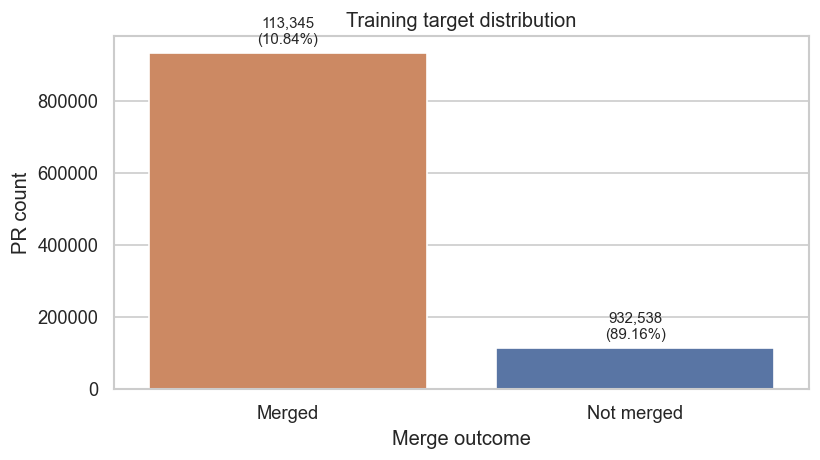

In [3]:
train_full = pd.read_csv(TRAIN_PATH, low_memory=False)
test_full = pd.read_csv(TEST_PATH, low_memory=False)

schema_summary = pd.DataFrame(
    [
        {"check": "train rows", "result": f"{len(train_full):,}"},
        {"check": "test rows", "result": f"{len(test_full):,}"},
        {"check": "train columns", "result": train_full.shape[1]},
        {"check": "test columns", "result": test_full.shape[1]},
        {"check": "same column names", "result": set(train_full.columns) == set(test_full.columns)},
        {"check": "same column order", "result": train_full.columns.equals(test_full.columns)},
        {"check": "target in train", "result": TARGET_COLUMN in train_full.columns},
        {"check": "target in test", "result": TARGET_COLUMN in test_full.columns},
        {"check": "explicit train nulls", "result": int(train_full.isna().sum().sum())},
        {"check": "explicit test nulls", "result": int(test_full.isna().sum().sum())},
        {"check": "duplicate train rows", "result": int(train_full.duplicated().sum())},
        {"check": "duplicate test rows", "result": int(test_full.duplicated().sum())},
    ]
)
target_dist = pd.concat(
    [target_distribution(train_full, "train"), target_distribution(test_full, "test")],
    ignore_index=True,
)
display(schema_summary)
display(target_dist)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=target_dist[target_dist["split"] == "train"],
    x="label",
    y="count",
    hue="label",
    order=["Merged", "Not merged"],
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=ax,
)
ax.set_title("Training target distribution")
ax.set_xlabel("Merge outcome")
ax.set_ylabel("PR count")
for patch, (_, row) in zip(ax.patches, target_dist[target_dist["split"] == "train"].set_index("label").loc[["Merged", "Not merged"]].reset_index().iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['percentage']:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", bbox_inches="tight")
plt.show()


## Leakage-aware feature review


In [4]:
feature_review = pd.DataFrame(
    [
        {"feature": TARGET_COLUMN, "status": "target", "reason": "Locked prediction target."},
        *[
            {"feature": feature, "status": "exclude_identifier", "reason": "Entity identifier; not a behavioral predictor."}
            for feature in exclude_ids
        ],
        *[
            {"feature": feature, "status": "exclude_post_outcome", "reason": "Depends on closure or post-decision information."}
            for feature in exclude_post_outcome
        ],
        *[
            {"feature": feature, "status": "hold_back_timing_sensitive", "reason": "Timing relative to merge decision is not yet defensible."}
            for feature in ambiguous_features
        ],
        *[
            {"feature": feature, "status": "candidate_safe", "reason": availability_reason(feature)}
            for feature in candidate_safe_features
        ],
    ]
)
display(
    feature_review.groupby("status", as_index=False)
    .agg(feature_count=("feature", "count"))
    .sort_values("status")
)
display(feature_review)


,status,feature_count
0,candidate_safe,32
1,exclude_identifier,4
2,exclude_post_outcome,3
3,hold_back_timing_sensitive,32
4,target,1


,feature,status,reason
0,merged_or_not,target,Locked prediction target.
1,id,exclude_identifier,Entity identifier; not a behavioral predictor.
2,project_id,exclude_identifier,Entity identifier; not a behavioral predictor.
3,creator_id,exclude_identifier,Entity identifier; not a behavioral predictor.
4,last_closer_id,exclude_identifier,Entity identifier; not a behavioral predictor.
...,...,...,...
67,test_churn,candidate_safe,Initial PR diff test-churn measure available b...
68,num_commits,candidate_safe,Current PR commit count from the submitted dif...
69,src_churn,candidate_safe,Initial PR source-churn measure available befo...
70,files_changed,candidate_safe,Initial PR diff size available before final cl...


## Exploratory data analysis on conservative features


files_changed        churn_addition         churn_deletion  \
                       mean median           mean  median           mean   
merged_or_not                                                              
Not merged          15.4410 2.0000       618.5550 22.0000       344.6100   
Merged              10.9080 2.0000       412.5720 16.0000       277.5760   

                     description_length         num_commits         
              median               mean  median        mean median  
merged_or_not                                                       
Not merged    5.0000            59.9190 26.0000      4.6960 2.0000  
Merged        5.0000            45.9530 20.0000      3.9840 2.0000

,feature,value,count,merge_rate_pct
0,first_pr,0,1012149,89.4500
1,first_pr,1,33734,80.6800
2,core_member,0,206724,82.5600
3,core_member,1,839159,90.7900
4,test_inclusion,0,825940,89.4300
5,test_inclusion,1,219943,88.1700
6,friday_effect,0,872033,89.1100
7,friday_effect,1,173850,89.4200
8,ci_exists,0,318880,87.0500
9,ci_exists,1,727003,90.0900


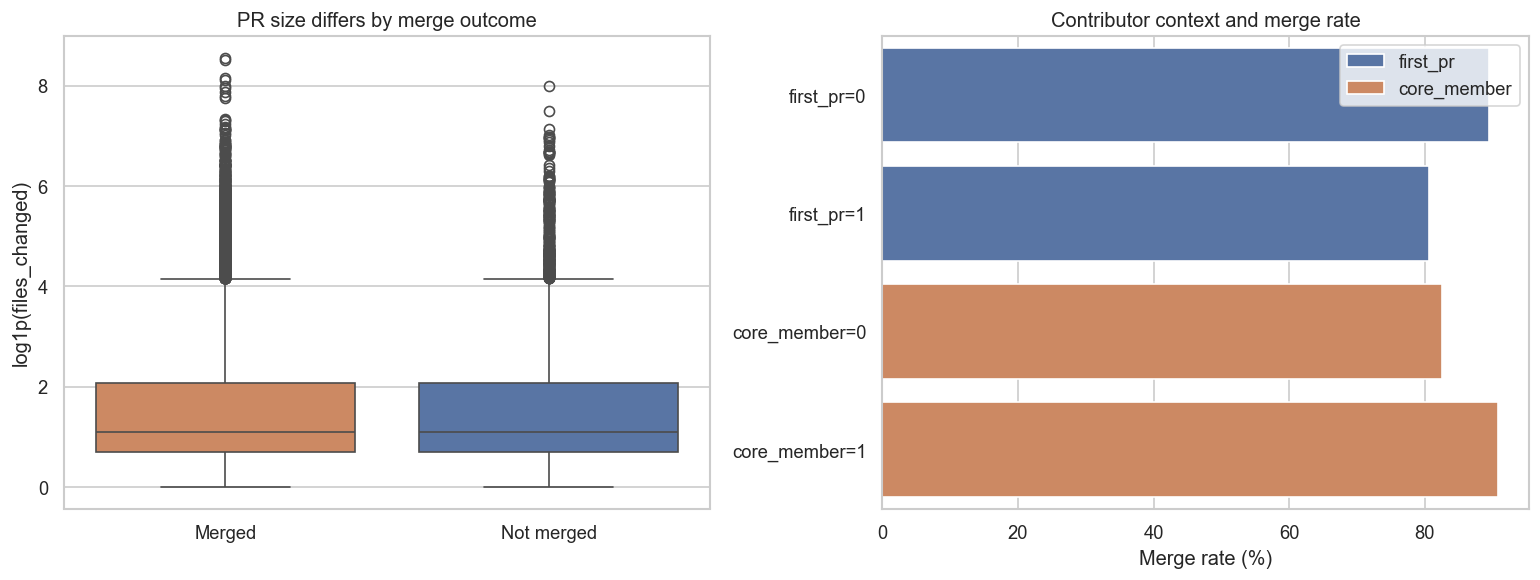

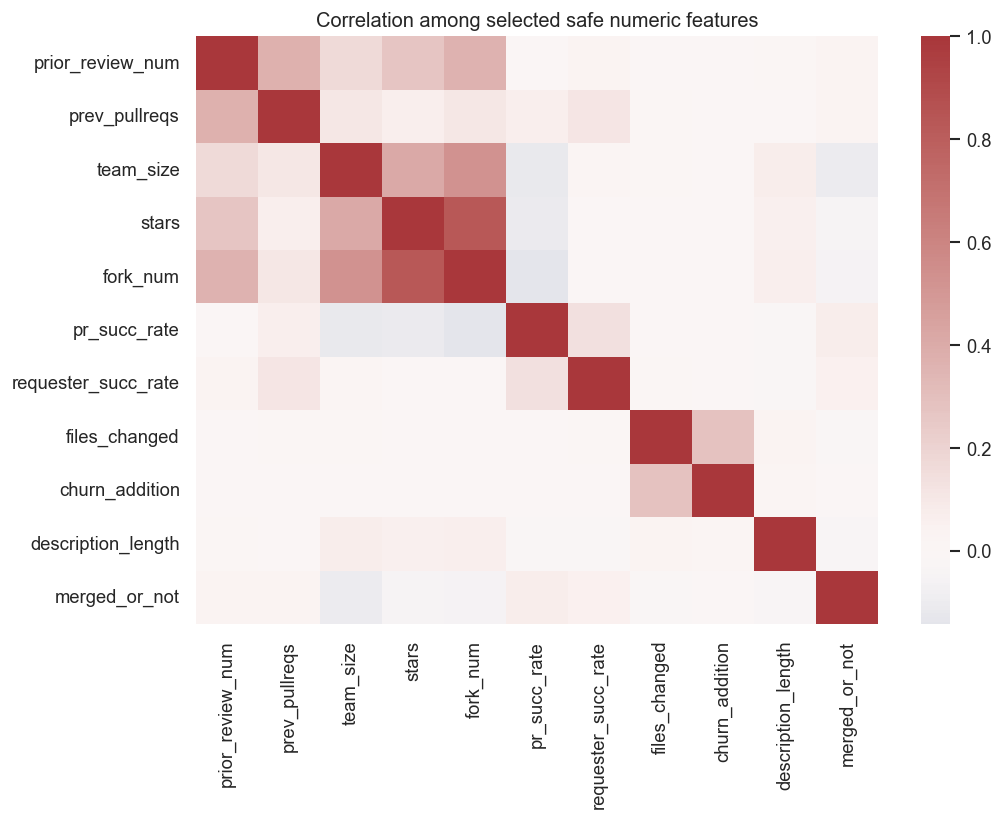

In [5]:
train_model = train_full[safe_usecols].copy()
test_model = test_full[safe_usecols].copy()

size_features = ["files_changed", "churn_addition", "churn_deletion", "description_length", "num_commits"]
size_summary = (
    train_model.groupby(TARGET_COLUMN)[size_features]
    .agg(["mean", "median"])
    .rename(index=TARGET_LABELS)
    .round(3)
)
display(size_summary)

binary_rate_features = ["first_pr", "core_member", "test_inclusion", "friday_effect", "ci_exists"]
binary_rates = pd.concat(
    [
        train_model.groupby(feature)[TARGET_COLUMN]
        .agg(merge_rate="mean", count="size")
        .reset_index()
        .rename(columns={feature: "value"})
        .assign(feature=feature, merge_rate_pct=lambda df: (df["merge_rate"] * 100).round(2))
        for feature in binary_rate_features
    ],
    ignore_index=True,
)[["feature", "value", "count", "merge_rate_pct"]]
display(binary_rates)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample_for_plot = stratified_sample(train_model[[TARGET_COLUMN, *size_features]], 60_000)
sample_for_plot["merge_label"] = sample_for_plot[TARGET_COLUMN].map(TARGET_LABELS)
sns.boxplot(
    data=sample_for_plot.assign(log_files_changed=np.log1p(sample_for_plot["files_changed"])),
    x="merge_label",
    y="log_files_changed",
    hue="merge_label",
    palette=["#DD8452", "#4C72B0"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("PR size differs by merge outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("log1p(files_changed)")

core_plot = binary_rates[binary_rates["feature"].isin(["first_pr", "core_member"])].copy()
core_plot["group"] = core_plot["feature"] + "=" + core_plot["value"].astype(str)
sns.barplot(data=core_plot, x="merge_rate_pct", y="group", hue="feature", dodge=False, ax=axes[1])
axes[1].set_title("Contributor context and merge rate")
axes[1].set_xlabel("Merge rate (%)")
axes[1].set_ylabel("")
axes[1].legend(title="")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_safe_feature_patterns.png", bbox_inches="tight")
plt.show()

corr_features = ["prior_review_num", "prev_pullreqs", "team_size", "stars", "fork_num", "pr_succ_rate", "requester_succ_rate", "files_changed", "churn_addition", "description_length", TARGET_COLUMN]
corr = train_model[corr_features].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation among selected safe numeric features")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "safe_feature_correlation.png", bbox_inches="tight")
plt.show()


## Supervised modeling and validation comparison


XGBoost unavailable, skipping optional baseline (XGBoostError).


,model,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,tn_not_merged,fp_not_merged,fn_merged,tp_merged
0,Random forest balanced,0.8168,0.7041,0.3094,0.5601,0.3986,0.9407,0.8481,0.8920,0.7845,0.4056,3945,3099,8806,49150
1,Hist gradient boosting weighted,0.7749,0.7109,0.2694,0.6292,0.3773,0.9462,0.7927,0.8626,0.7834,0.4123,4432,2612,12017,45939
2,Decision tree balanced,0.7418,0.6662,0.2259,0.5697,0.3235,0.9358,0.7627,0.8405,0.7276,0.3409,4013,3031,13752,44204
3,Logistic regression balanced,0.6379,0.6265,0.1716,0.6119,0.2681,0.9315,0.6411,0.7595,0.6735,0.2185,4310,2734,20802,37154
4,Dummy majority,0.8916,0.5000,0.0000,0.0000,0.0000,0.8916,1.0000,0.9427,0.5000,0.1084,0,7044,0,57956


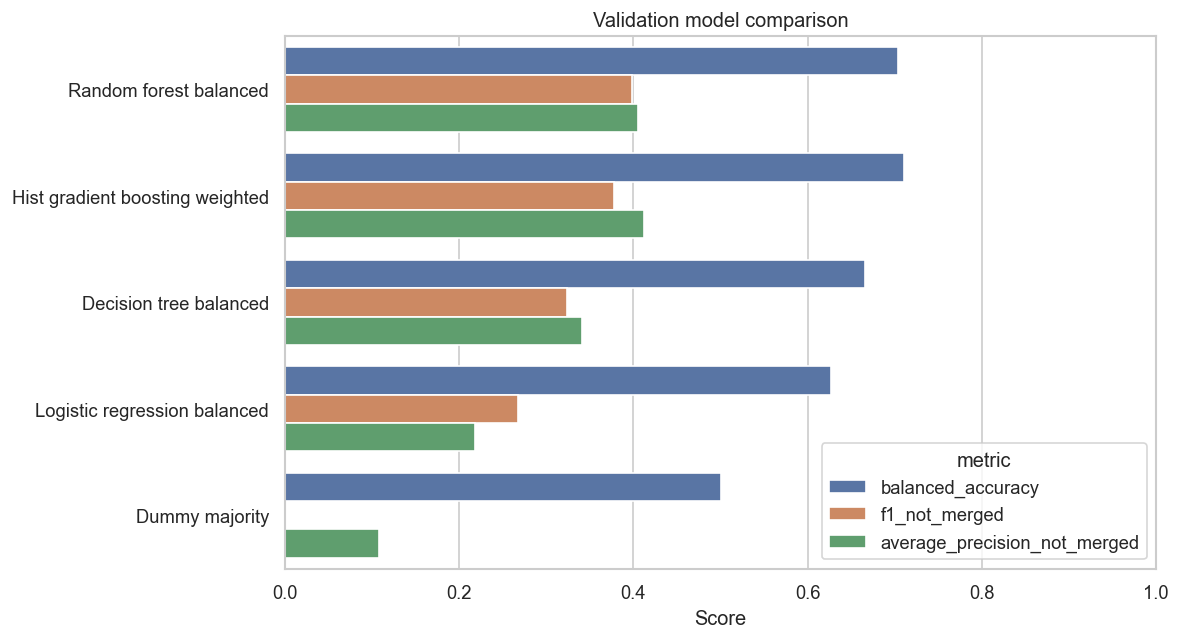

'Random forest balanced'

In [6]:
MODEL_SAMPLE_SIZE = 260_000
comparison, fitted_models, validation_data = fit_and_compare(train_model, MODEL_SAMPLE_SIZE)
comparison.to_csv(FINAL_DIR / "model_comparison.csv", index=False)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5.5))
metric_plot = comparison.melt(
    id_vars="model",
    value_vars=["balanced_accuracy", "f1_not_merged", "average_precision_not_merged"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=metric_plot, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Validation model comparison")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

selected_model_name = comparison.iloc[0]["model"]
selected_model_name


## Final evaluation on the untouched test split


XGBoost unavailable, skipping optional baseline (XGBoostError).


,model,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,tn_not_merged,fp_not_merged,fn_merged,tp_merged
0,Random forest balanced,0.8111,0.6729,0.2852,0.4967,0.3623,0.9330,0.8492,0.8891,0.7356,0.3581,13968,14154,35007,197066


,Predicted not merged,Predicted merged
Actual not merged,13968,14154
Actual merged,35007,197066


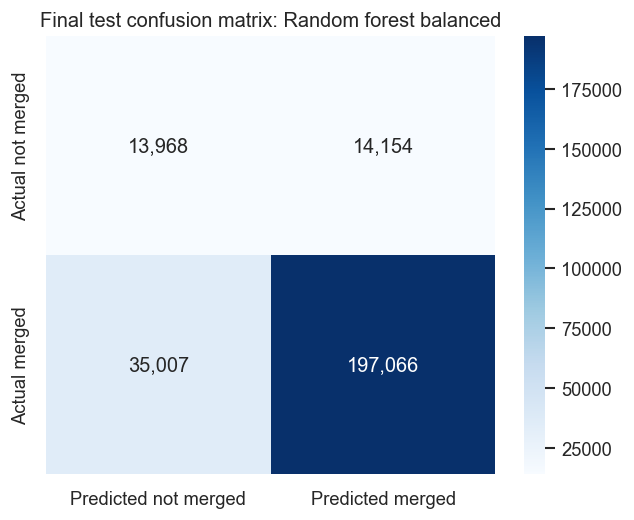

,feature,importance
0,prior_review_num,0.1471
1,contrib_perc_commit,0.1132
2,open_pr_num,0.0524
3,pr_succ_rate,0.0508
4,sloc,0.0458
5,fork_num,0.0454
6,stars,0.0400
7,test_lines_per_kloc,0.0392
8,prior_interaction,0.0389
9,prev_pullreqs,0.0377


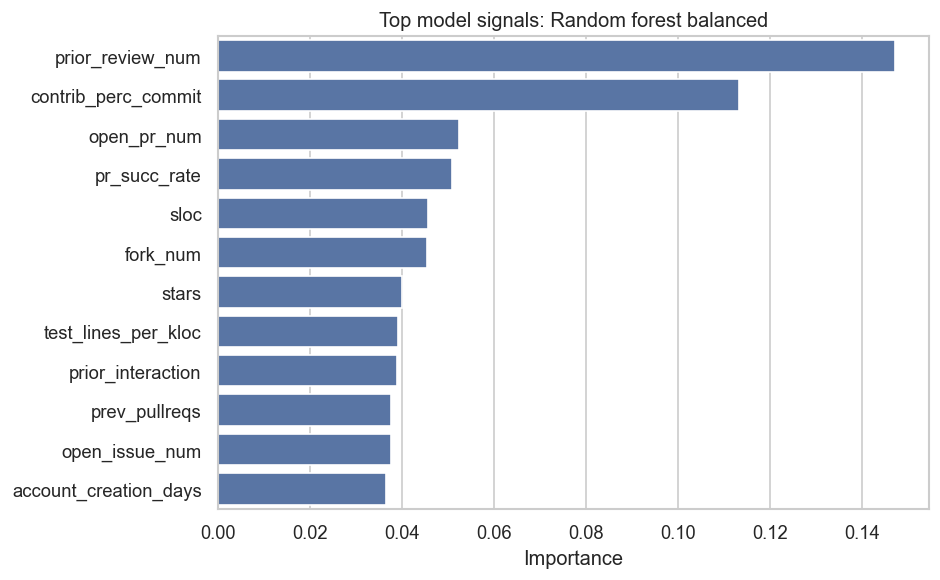

In [7]:
final_train_df = stratified_sample(train_model[safe_usecols], MODEL_SAMPLE_SIZE)
X_final_train = final_train_df[candidate_safe_features]
y_final_train = final_train_df[TARGET_COLUMN]
X_test = test_model[candidate_safe_features]
y_test = test_model[TARGET_COLUMN]

final_model = clone(build_models(y_final_train)[selected_model_name])
final_model.fit(X_final_train, y_final_train)
final_metrics = pd.DataFrame([score_pipeline(selected_model_name, final_model, X_test, y_test)])
final_metrics.to_csv(FINAL_DIR / "final_test_metrics.csv", index=False)
display(final_metrics)

cm = confusion_matrix(y_test, final_model.predict(X_test), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Actual not merged", "Actual merged"], columns=["Predicted not merged", "Predicted merged"])
cm_df.to_csv(FINAL_DIR / "final_confusion_matrix.csv")
display(cm_df)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title(f"Final test confusion matrix: {selected_model_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_confusion_matrix.png", bbox_inches="tight")
plt.show()

importances = feature_importance_table(final_model)
importances.to_csv(FINAL_DIR / "feature_importance.csv", index=False)
display(importances.head(15))
if not importances.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=importances.head(12), x="importance", y="feature", ax=ax)
    ax.set_title(f"Top model signals: {selected_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()


## Unsupervised analysis: clustering PR profiles


,k,silhouette,inertia
0,2,0.4814,"1,772,805.2059"
1,3,0.1909,"1,656,190.0299"
2,4,0.1181,"1,529,961.2939"
3,5,0.1132,"1,469,356.2628"
4,6,0.1371,"1,389,420.0949"


,cluster,pr_count,merge_rate,not_merged_rate,median_files_changed,median_churn_addition,median_description_length,median_num_commits,median_team_size,median_stars,median_requester_succ_rate
0,0,66400,89.5600,10.4400,3.0000,17.0000,20.0000,2.0000,6.0000,118.0000,1.0000
1,1,3600,81.8300,18.1700,2.0000,11.0000,36.0000,2.0000,35.0000,"17,139.5000",0.9857


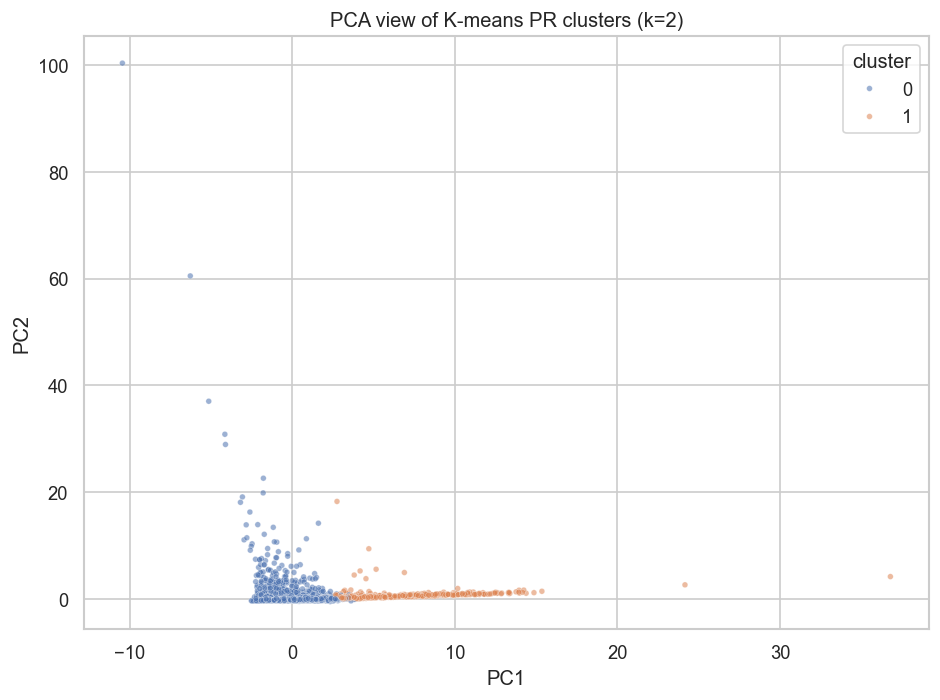

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

CLUSTER_SAMPLE_SIZE = 70_000
cluster_df = stratified_sample(train_model[safe_usecols], CLUSTER_SAMPLE_SIZE)
X_cluster_raw = cluster_df[candidate_safe_features]
cluster_preprocessor = make_preprocessor()
X_cluster = cluster_preprocessor.fit_transform(X_cluster_raw)

silhouette_rows = []
silhouette_eval_size = min(12_000, X_cluster.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
eval_indices = rng.choice(X_cluster.shape[0], size=silhouette_eval_size, replace=False)
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(X_cluster[eval_indices], labels[eval_indices])
    silhouette_rows.append({"k": k, "silhouette": score, "inertia": model.inertia_})

k_selection = pd.DataFrame(silhouette_rows)
k_selection.to_csv(FINAL_DIR / "cluster_k_selection.csv", index=False)
display(k_selection)

selected_k = int(k_selection.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
kmeans = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

profile_features = ["files_changed", "churn_addition", "description_length", "num_commits", "team_size", "stars", "requester_succ_rate"]
cluster_profile = (
    cluster_df.groupby("cluster")
    .agg(
        pr_count=(TARGET_COLUMN, "size"),
        merge_rate=(TARGET_COLUMN, "mean"),
        not_merged_rate=(TARGET_COLUMN, lambda values: 1 - values.mean()),
        **{f"median_{feature}": (feature, "median") for feature in profile_features},
    )
    .reset_index()
)
cluster_profile["merge_rate"] = (cluster_profile["merge_rate"] * 100).round(2)
cluster_profile["not_merged_rate"] = (cluster_profile["not_merged_rate"] * 100).round(2)
cluster_profile.to_csv(FINAL_DIR / "cluster_profile.csv", index=False)
display(cluster_profile)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(X_cluster)
plot_points = pd.DataFrame(
    {
        "pc1": pca_points[:, 0],
        "pc2": pca_points[:, 1],
        "cluster": cluster_df["cluster"].astype(str),
        "merge_label": cluster_df[TARGET_COLUMN].map(TARGET_LABELS),
    }
)
plot_points = plot_points.sample(n=min(12_000, len(plot_points)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_points, x="pc1", y="pc2", hue="cluster", s=12, alpha=0.55, ax=ax)
ax.set_title(f"PCA view of K-means PR clusters (k={selected_k})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_pca.png", bbox_inches="tight")
plt.show()


## Final interpretation


In [9]:
best_validation = comparison.iloc[0]
test_row = final_metrics.iloc[0]
top_cluster = cluster_profile.sort_values("not_merged_rate", ascending=False).iloc[0]
display(Markdown(f'''
**Final supervised result.** The selected model is **{selected_model_name}**, chosen by validation not-merged F1. On the untouched test split it reaches:

- Balanced accuracy: `{test_row["balanced_accuracy"]:.3f}`
- Not-merged precision: `{test_row["precision_not_merged"]:.3f}`
- Not-merged recall: `{test_row["recall_not_merged"]:.3f}`
- Not-merged F1: `{test_row["f1_not_merged"]:.3f}`
- Not-merged average precision: `{test_row["average_precision_not_merged"]:.3f}`

**Interpretation.** PR-level metadata and change-size features contain useful signal, but the class imbalance means raw accuracy is not enough. The analysis should be read as association and prediction, not causality.

**Unsupervised result.** K-means identified `{selected_k}` PR profile clusters without using the target during fitting. Cluster `{int(top_cluster["cluster"])}` has the highest observed not-merged rate after profiling (`{top_cluster["not_merged_rate"]:.2f}%`), which makes it useful for interpretation rather than a separate predictive model.

**Threats to validity.** Feature timing remains the main risk. Discussion, sentiment, CI progression, and closure-derived variables were held back unless their availability before the outcome could be defended. The final model also uses a stratified training sample for runtime, so results should be framed as a reproducible course-scale analysis rather than an industrial deployment.
'''))



**Final supervised result.** The selected model is **Random forest balanced**, chosen by validation not-merged F1. On the untouched test split it reaches:

- Balanced accuracy: `0.673`
- Not-merged precision: `0.285`
- Not-merged recall: `0.497`
- Not-merged F1: `0.362`
- Not-merged average precision: `0.358`

**Interpretation.** PR-level metadata and change-size features contain useful signal, but the class imbalance means raw accuracy is not enough. The analysis should be read as association and prediction, not causality.

**Unsupervised result.** K-means identified `2` PR profile clusters without using the target during fitting. Cluster `1` has the highest observed not-merged rate after profiling (`18.17%`), which makes it useful for interpretation rather than a separate predictive model.

**Threats to validity.** Feature timing remains the main risk. Discussion, sentiment, CI progression, and closure-derived variables were held back unless their availability before the outcome could be defended. The final model also uses a stratified training sample for runtime, so results should be framed as a reproducible course-scale analysis rather than an industrial deployment.
